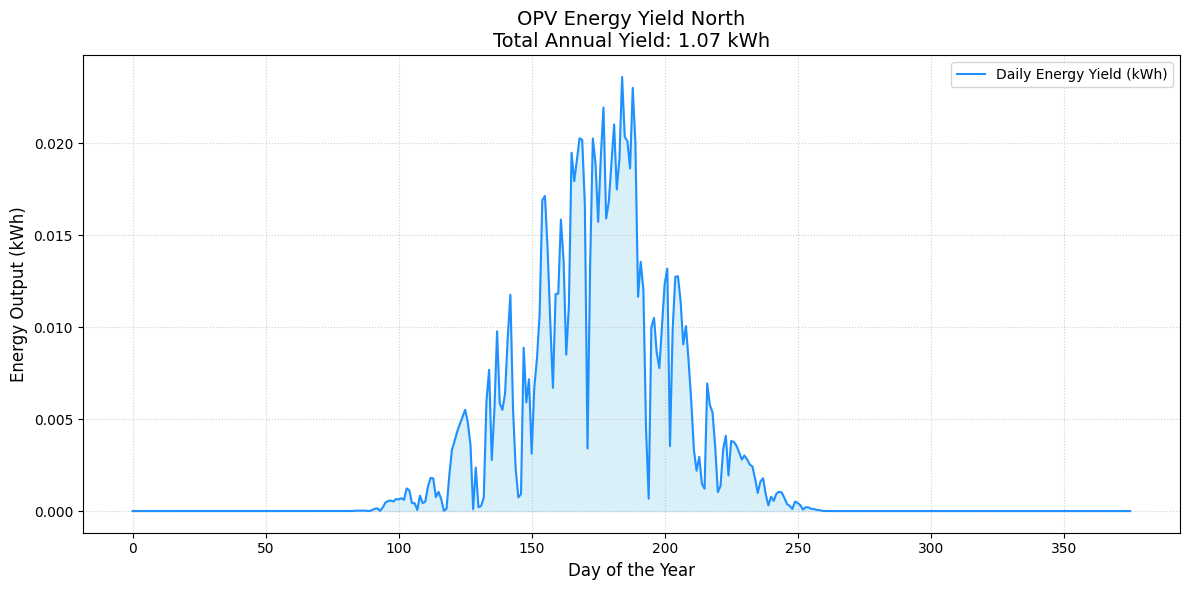

Simulation completed successfully!
Estimated Annual Yield (Daily-Based Structure): 1.07 kWh


In [79]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_yield_daily_data(lat, lon, tilt, azimuth, excel_path):
    try:
        df = pd.read_excel(excel_path, engine='openpyxl')
        # removes spaces from names
        df.columns = df.columns.str.strip()

        # fills empty or damaged data with the data from day before
        df['Temp_Tag'] = df['Temp_Tag'].ffill().fillna(25.0)
        df['Sonnenscheindauer in h'] = df['Sonnenscheindauer in h'].ffill().fillna(0.0)

    except Exception as e:
        return f"Fehler beim Laden: {e}"
    
    # --- PARAMETERS (Based on HeliaSol Datasheet) ---
    n_modules = 2                  # 2 wall or 5 roof -- amount of moduls
    power_total = 55.0 * n_modules    # Gesamtleistung in Watt (Wp)

    # Temperature Coefficients from Datasheet
    temp_coeff_high = -0.0011   # 0.0% loss till 65°C, after -0.11% pro Grad
     
    total_yield = 0
    yield_history = []
    
    for index, row in df.iterrows():

        day = index + 1
        t_day = row.get('Temp_Tag', 25)   #max daily tempreture
        sun_h = row.get('Sonnenscheindauer in h', 0) #sun shining hours
        
        # Cloud factor: Adjusting theoretical max radiation to real weather
        cloud_factor = min(1.0, sun_h / 12) if sun_h > 0 else 0.15 # 0.15 = diffuses Restlicht
        daily_energy_kwh = 0
        

        for hour in range(24):
            # --- START EXAMPLE 1.1: Solar Geometry & Positioning ---
            # Declination: Position of the sun relative to the equator
            Ds = 23.45 * math.sin(math.radians(360 * (day - 81) / 365))
            # Hour Angle: Earth's rotation (15° per hour)
            Hs = (hour - 12) * 15
            # Altitude Angle (Alpha): Elevation of the sun above the horizon
            sin_alpha = (math.sin(math.radians(lat)) * math.sin(math.radians(Ds)) +
                         math.cos(math.radians(lat)) * math.cos(math.radians(Ds)) * math.cos(math.radians(Hs)))
            alpha = math.degrees(math.asin(max(-1, min(1, sin_alpha))))
            # --- END EXAMPLE 1.1 ---

            if alpha > 0:
                # 2. Solar Azimuth (Sun direction)
                # Calculation of the sun's horizontal position
                num = (math.sin(math.radians(Ds)) * math.cos(math.radians(lat)) - 
                       math.cos(math.radians(Ds)) * math.sin(math.radians(lat)) * math.cos(math.radians(Hs)))
                cos_azimuth_sun = num / math.cos(math.radians(alpha))
                cos_azimuth_sun = max(-1, min(1, cos_azimuth_sun))
                azimuth_sun = math.degrees(math.acos(cos_azimuth_sun))
                
                if Hs > 0: # Correction for afternoon
                    azimuth_sun = 360 - azimuth_sun

                # AOI: Angle of Incidence correction for tilted surface
                # Combining module tilt and module azimuth with sun position
                cos_aoi = (math.sin(math.radians(alpha)) * math.cos(math.radians(tilt)) +
                           math.cos(math.radians(alpha)) * math.sin(math.radians(tilt)) * math.cos(math.radians(azimuth_sun - azimuth)))
                aoi_corr = max(0, cos_aoi)

                # GHI: Global Horizontal Irradiance estimation
                ghi = 1367 * 0.7 * math.sin(math.radians(alpha)) * cloud_factor
                # Normalize irradiance to STC (1000 W/m²)
                effective_irradiance_ratio = (ghi / 1000) * max(0, aoi_corr)
                

                #Cell Temperature: Heating of the module due to solar radiation
                t_cell = t_day + (ghi / 800) * 15 
                # Performance Ratio: Power loss/gain based on temperature
                if t_cell <= 65:
                    perf_ratio = 1.0  # Stable performance (0.0%/°C) up to 65°C
                else:
                    perf_ratio = 1 + temp_coeff_high * (t_cell - 65)
                
                # Final energy calculation (Power * Ratio * Temperature Factor)
                hourly_kwh = (power_total * effective_irradiance_ratio * perf_ratio) / 1000
                daily_energy_kwh += hourly_kwh
        
        total_yield += daily_energy_kwh
        yield_history.append(daily_energy_kwh) # Tag speichern

     # --- Plotting ---
    plt.figure(figsize=(12, 6))
    plt.plot(yield_history, color='dodgerblue', linewidth=1.5, label='Daily Energy Yield (kWh)')
    
    # Chart Styling
    plt.title(f'OPV Energy Yield North\nTotal Annual Yield: {total_yield:.2f} kWh', fontsize=14)
    plt.xlabel('Day of the Year', fontsize=12)
    plt.ylabel('Energy Output (kWh)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    
    # Visualizing the seasonality
    plt.fill_between(range(len(yield_history)), yield_history, color='skyblue', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
        
    return total_yield

# --- Start ---
excel_file = 'Wetter_Daten.xlsx'
# Standort-Daten (Klagenfurt)
lat = 46.61 
lon= 14.2
# Ausrichtung
tilt=90 # 16.26 roof tilt, wall 90
azimuth=0 # Süden 180, West 270, Ost 90, Südost 135,  

result = calculate_yield_daily_data(lat, lon, tilt, azimuth, excel_file)
print(f"Simulation completed successfully!")
print(f"Estimated Annual Yield (Daily-Based Structure): {result:.2f} kWh")

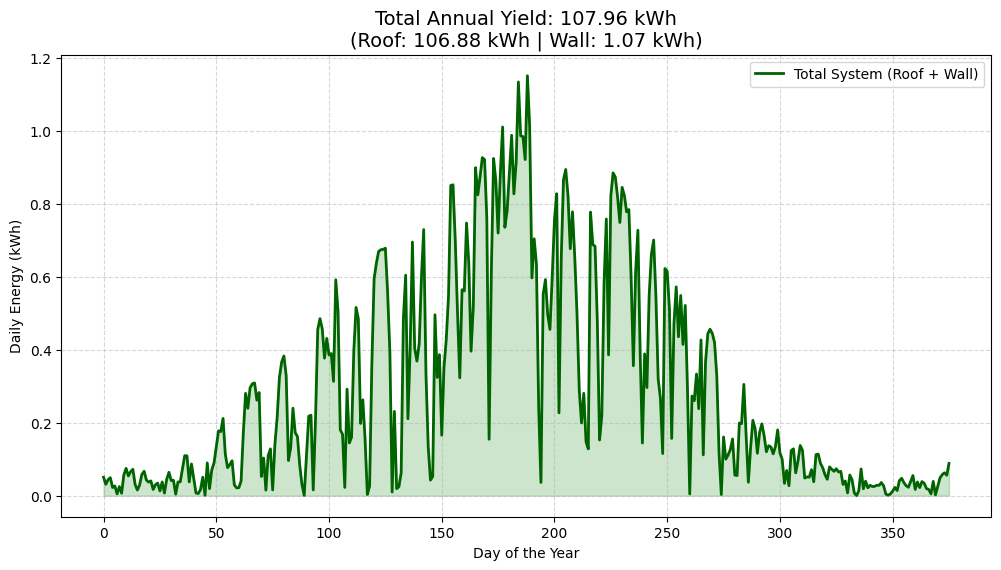

In [78]:
import math
import pandas as pd
import matplotlib.pyplot as plt

def calculate_total_system_yield(lat, lon, roof_tilt, roof_azimuth,wall_azimuth, wall_tilt,excel_path):
    # --- System Configuration ---
    # 5 modules on the roof
    n_roof = 5
    # 2 modules on the wall (vertical, opposite direction)
    n_wall = 2

    def run_sub_simulation(tilt, azimuth, n_modules):
        try:
            # Load and clean data immediately to avoid None values
            df = pd.read_excel(excel_path, engine='openpyxl')
            df.columns = df.columns.str.strip()
            
            # Cleaning logic to fix the "spikes" and "None" errors
            df['Temp_Tag'] = pd.to_numeric(df['Temp_Tag'], errors='coerce').ffill().fillna(25.0)
            df['Sonnenscheindauer in h'] = pd.to_numeric(df['Sonnenscheindauer in h'], errors='coerce').ffill().fillna(0.0)
        except Exception as e:
            print(f"Sub-simulation error: {e}")
            return 0.0, [0.0] * 365 # Return zeros so the math doesn't break

        power_total = 55.0 * n_modules # Based on Heliatek 55W
        temp_coeff_high = -0.0011 # Losses above 65°C
        total_yield = 0
        history = []

        for index, row in df.iterrows():
            day = index + 1
            t_day, sun_h = row['Temp_Tag'], row['Sonnenscheindauer in h']
            cloud_factor = min(1.0, sun_h / 12) if sun_h > 0 else 0.15
            daily_sum = 0
            
            for hour in range(24):
                # --- START EXAMPLE 1.1: Geometry ---
                Ds = 23.45 * math.sin(math.radians(360 * (day - 81) / 365))
                Hs = (hour - 12) * 15
                sin_alpha = (math.sin(math.radians(lat)) * math.sin(math.radians(Ds)) +
                             math.cos(math.radians(lat)) * math.cos(math.radians(Ds)) * math.cos(math.radians(Hs)))
                alpha = math.degrees(math.asin(max(-1, min(1, sin_alpha))))
                
                if alpha > 0:
                    # Sun Azimuth
                    num = (math.sin(math.radians(Ds)) * math.cos(math.radians(lat)) - 
                           math.cos(math.radians(Ds)) * math.sin(math.radians(lat)) * math.cos(math.radians(Hs)))
                    cos_az_s = max(-1, min(1, num / math.cos(math.radians(alpha))))
                    az_s = 360 - math.degrees(math.acos(cos_az_s)) if Hs > 0 else math.degrees(math.acos(cos_az_s))
                    
                    # Angle of Incidence (AOI)
                    cos_aoi = (math.sin(math.radians(alpha)) * math.cos(math.radians(tilt)) +
                               math.cos(math.radians(alpha)) * math.sin(math.radians(tilt)) * math.cos(math.radians(az_s - azimuth)))
                    aoi_corr = max(0, cos_aoi)
                    
                    # --- START EXAMPLE 2.5: Performance ---
                    ghi = 1367 * 0.7 * math.sin(math.radians(alpha)) * cloud_factor
                    t_cell = t_day + (ghi / 800) * 15
                    perf_ratio = 1.0 if t_cell <= 65 else 1 + temp_coeff_high * (t_cell - 65)
                    
                    daily_sum += (power_total * (ghi / 1000) * aoi_corr * perf_ratio) / 1000
            
            total_yield += daily_sum
            history.append(daily_sum)
            
        return total_yield, history

    # Run simulations
    yield_roof, hist_roof = run_sub_simulation(roof_tilt, roof_azimuth, n_roof)
    yield_wall, hist_wall = run_sub_simulation(wall_tilt, wall_azimuth, n_wall)
    
    # Combined Results
    total_yield = yield_roof + yield_wall
    combined_hist = [r + w for r, w in zip(hist_roof, hist_wall)]

    # --- Plotting ---
    plt.figure(figsize=(12, 6))
    plt.plot(combined_hist, label='Total System (Roof + Wall)', color='darkgreen', linewidth=2)
    plt.fill_between(range(len(combined_hist)), combined_hist, color='green', alpha=0.2)
    plt.title(f'Total Annual Yield: {total_yield:.2f} kWh\n(Roof: {yield_roof:.2f} kWh | Wall: {yield_wall:.2f} kWh)', fontsize=14)
    plt.xlabel('Day of the Year')
    plt.ylabel('Daily Energy (kWh)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    return total_yield

# Start Parameters
lat, lon = 46.61, 14.2
excel_file = 'Wetter_Daten.xlsx'
roof_tilt=16.42 
roof_azimuth=180
wall_tilt=90
wall_azimuth=0

# Set Roof params (the code calculates the wall automatically as 90° and opposite direction)
final_result = calculate_total_system_yield(lat, lon, roof_tilt, roof_azimuth,wall_azimuth,wall_tilt,excel_path=excel_file)